### Derivatives of Exponential Functions
Use the function we defined in the first notebook to plot the derivative of $y = 2^x$.

In [15]:
from collections.abc import Callable
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def calculate_derivative_at_point(f: Callable, x: float, delta: float = 1e-7):
    """
    Calculates a numerical approximation to the derivative of the specified function
    at the given point x.

    Args:
        f (Callable): The function to calculate the derivative of
        x (float): The point at which to calculate the derivative
        delta (float, optional): The step size for the numerical approximation. Defaults to 1e-7.

    Returns:
        float: The numerical approximation to the derivative of the function at the given point x
    """
    return (f(x + delta) - f(x)) / delta

def plot_derivative(func: Callable, 
                    derivative_func: Callable = None, 
                    min_x: int = -10, 
                    max_x: int = 10):
    """
    Plots the function and its derivative. 
    The `derivative` parameter is optional and can be provided as a separate function.
    If it's not provided, the derivative will be calculated automatically

    Args:
        func (Callable): The function to plot
        derivative_func (Callable, optional): The derivative of the function to plot. Defaults to None.
        min_x (int, optional): The minimum x value to plot. Defaults to -10.
        max_x (int, optional): The maximum x value to plot. Defaults to 10.
    """
    # We're using vectorized functions to make our code simpler: this only hides the for-loop,
    # it doesn't provide any performance gain
    vectorized_function = np.vectorize(func)
    
    x = np.linspace(min_x, max_x, 100)
    y = vectorized_function(x)
    
    dy = []
    # CASE 1: We don't have a derivative function, so we calculate it automatically
    if derivative_func is None:
        dy = np.vectorize(calculate_derivative_at_point)(func, x)
    # CASE 1: We have a derivative function, explicitly provided
    else:
        dy = np.vectorize(derivative_func)(x)

    plt.plot(x, y, label = "f(x)")
    plt.plot(x, dy, label = "f'(x)")
    plt.xlim(min_x, max_x)
    plt.legend()
    plt.show()

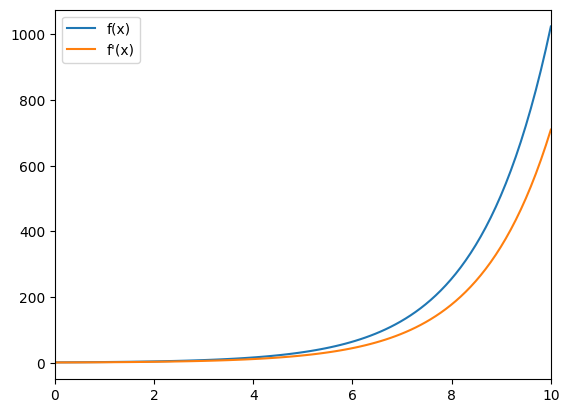

In [17]:
plot_derivative(lambda x: 2 ** x, min_x = 0, max_x = 10)

The function and its derivative look closely related, only the derivative seems to grow a bit slower than the function. Let's confirm that by looking at a broader range:

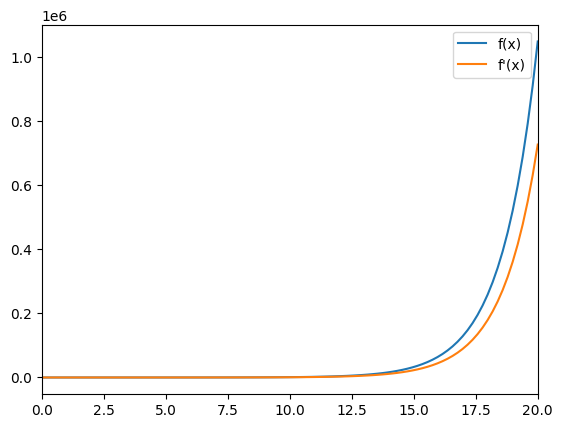

In [18]:
plot_derivative(lambda x: 2 ** x, min_x = 0, max_x = 20)

The same pattern will continue if we try to plot any exponential function, e.g. $y = 3^x$, $y = 4^x$ and so on, if the base of the exponent is greater than 1. If we want to plot, say, $y = 0,5^x$, we'll get a slightly different result. Note that the functions look more or less the same, only their signs are flipped.

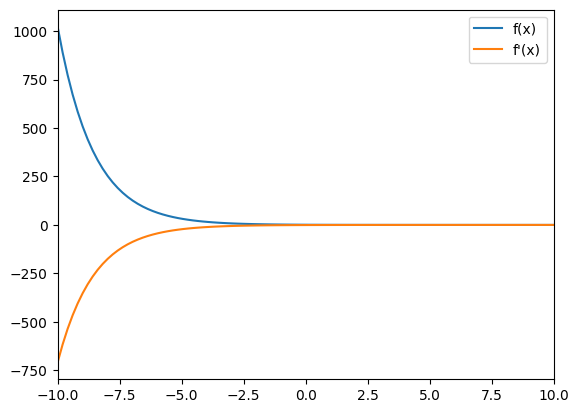

In [19]:
plot_derivative(lambda x: 0.5 ** x)

Very interesting things happen if we plot $y = e^x$:

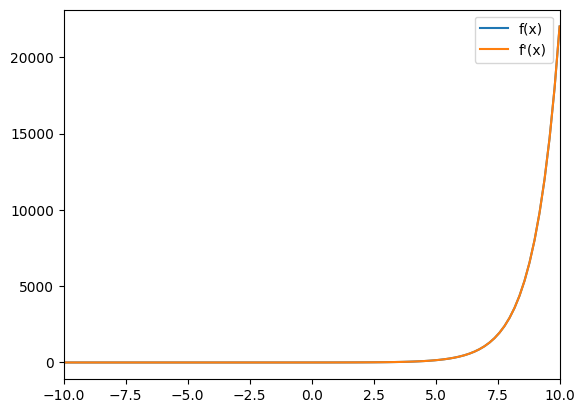

In [20]:
plot_derivative(np.exp)

The plots overlap. This means that

$$ (e^x)' = e^x $$

Also:
$$ (e^x)'' = e^x $$
$$ (e^x)''' = e^x $$
... and so on. **This is the only function whose rate of change (derivative) is equal to the function itself**. This property makes it even more interesting for science and math.

Also, do you remember that $e^{i\varphi} = \cos(\varphi) + i\sin(\varphi)$? This constant never ceases to amaze, right ... :-) 
